In [11]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [12]:
words = open('data/names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [13]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [14]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [15]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WaveNetResNet(nn.Module):
    def __init__(self, vocab_size, n_embd=10, n_hidden=68):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, n_embd)
        
        self.conv1 = nn.Conv1d(n_embd,   n_hidden, kernel_size=2, dilation=1)
        self.bn1   = nn.BatchNorm1d(n_hidden)
        
        self.conv2 = nn.Conv1d(n_hidden, n_hidden, kernel_size=2, dilation=2)
        self.bn2   = nn.BatchNorm1d(n_hidden)
        
        self.conv3 = nn.Conv1d(n_hidden, n_hidden, kernel_size=2, dilation=4)
        self.bn3   = nn.BatchNorm1d(n_hidden)
        
        self.fc = nn.Linear(n_hidden, vocab_size)
        
        with torch.no_grad():
            self.fc.weight *= 0.1

    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)   # (B, n_embd, L)
        
        # first layer has no residual — shape changes n_embd → n_hidden
        x = F.pad(x, (1, 0))
        x = torch.tanh(self.bn1(self.conv1(x)))  # (B, n_hidden, L)
        
        # residual connection from here — shape is consistent n_hidden → n_hidden
        residual = x
        x = F.pad(x, (2, 0))
        x = torch.tanh(self.bn2(self.conv2(x)))  # (B, n_hidden, L)
        x = x + residual                          # (B, n_hidden, L) ← addition, shape unchanged

        residual = x
        x = F.pad(x, (4, 0))
        x = torch.tanh(self.bn3(self.conv3(x)))  # (B, n_hidden, L)
        x = x + residual                          # (B, n_hidden, L) ← addition, shape unchanged
        
        x = x[:, :, -1]
        x = self.fc(x)
        return x


model = WaveNetResNet(vocab_size)

parameters = list(model.parameters())
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

22601


In [28]:
max_steps = 100000
batch_size = 32
lossi = []
optim = torch.optim.SGD(parameters, lr=0.1)
for i in range(max_steps):
    model.train()
    # mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)
    
    # backward pass
    optim.zero_grad()
    loss.backward()
    
    optim.step()
    
    #track stats
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps} {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/100000 3.2916
  10000/100000 2.1616
  20000/100000 2.0619
  30000/100000 2.5061
  40000/100000 1.6751
  50000/100000 1.9691
  60000/100000 1.9812
  70000/100000 2.0436
  80000/100000 2.1746
  90000/100000 2.1031


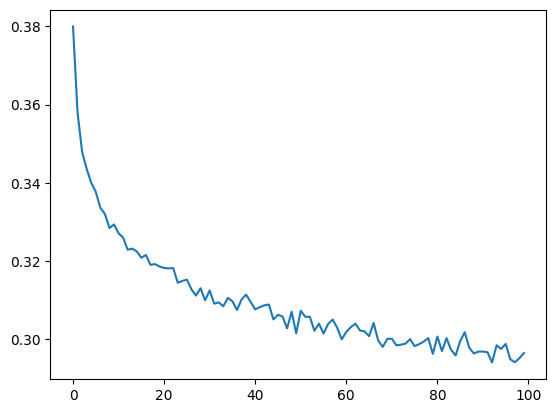

In [29]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [30]:
@torch.no_grad()
def split_loss(split):
    model.eval()
    X, Y = {'train': (Xtr, Ytr), 'dev': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    logits = model(X)
    loss = F.cross_entropy(logits, Y)
    print(f'{split} loss: {loss.item():.4f}')
    print(f"log loss - {split}: {loss.log10().item():.4f}")

split_loss('train')
split_loss('dev')

train loss: 1.9836
log loss - train: 0.2975
dev loss: 2.0751
log loss - dev: 0.3170


In [23]:
model.eval()
for _ in range(20) :
    out = []
    context = [0] * block_size
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

wazeem.
gabesha.
areed.
kelyn.
cebrasia.
teonle.
lillani.
presse.
arishm.
kell.
khraya.
artlyn.
shahni.
quidhya.
emerie.
avane.
riani.
aaniya.
sii.
fraiden.
